In [41]:
# # Import libraries

import pylab as pl
import numpy as np
# from astropy.visualization import quantity_support
# from astropy import units as u
# from astropy import wcs
import matplotlib as mpl


# # pl.rcParams['figure.facecolor']='w'

from spectral_cube import SpectralCube
from pvextractor import extract_pv_slice, Path
import matplotlib.pyplot as plt

# import pyspeckit
import astropy.units as u
import astropy.wcs as wcs
# import aplpy as aplpy
# from astropy.io import fits

# from astropy.visualization.wcsaxes import WCSAxes
from astropy.wcs import WCS

from astropy.coordinates import SkyCoord 
from astropy.wcs.utils import skycoord_to_pixel 
from astropy.wcs.utils import pixel_to_skycoord

from matplotlib.patches import Ellipse

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # or "Computer Modern"
    "font.size": 14,

    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,

    "mathtext.fontset": "cm",  # Computer Modern for LaTeX math
})


In [2]:
# Define contour, path, and beam functions

def plot_contours(data_array, color, sigma, sigma_min, sigma_max, sigma_step, ax, extent=None):
    sigma_levels = np.arange(sigma_min, sigma_max + sigma_step, sigma_step)
    levels = sigma * sigma_levels

    return ax.contour(
        data_array,
        levels=levels,
        colors=color,
        linewidths=0.5,
        origin='lower',
        extent=extent,
    )

def beam(beam_minor, beam_major, beam_pa, beam_xposition, beam_yposition):
    # Set beam location
    beam_x = ra_offsets.min() + beam_xposition  
    beam_y = dec_offsets.min() + beam_yposition

    # Create the beam ellipse
    return Ellipse(
        (beam_x, beam_y),
        width=beam_major,
        height=beam_minor,
        angle=beam_pa,
        edgecolor='black',
        facecolor='black',
        alpha=0.7,
        zorder=10
    )


# 12CO

In [3]:
cube_12CO=SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/CO/HOPS164_CO_Tp12m7m_Combine_pbcor_masked.fits')
cube_12CO.allow_huge_operations = True 
cube_12CO = cube_12CO.with_spectral_unit(u.km/u.s).to(u.K)

In [4]:
# Coordinates
marker_coord = SkyCoord("5h37m00.425s", "-6d37m10.89s", frame='icrs')
x_marker, y_marker = skycoord_to_pixel(marker_coord, cube_12CO.wcs.celestial)
print(x_marker, y_marker)

# Create a sky offset frame centered on the marker
offset_frame = marker_coord.skyoffset_frame()

228.60662394208083 220.4771254368455


In [5]:
# Access robust data
data_robust = cube_12CO.hdu.data

# Convert pixel grid to world coordinates
nx = cube_12CO.shape[1]
ny = cube_12CO.shape[2]
y_pix, x_pix = np.mgrid[:ny, :nx]
sky = pixel_to_skycoord(x_pix, y_pix, cube_12CO.wcs.celestial)

# Convert sky coordinates to offset frame
offset_coords = sky.transform_to(offset_frame)
ra_offsets = -offset_coords.lon.arcsec
dec_offsets = offset_coords.lat.arcsec

extent=[
            ra_offsets.min(), ra_offsets.max(),
            dec_offsets.min(), dec_offsets.max()
        ]

# Set Offset Path

In [6]:
# Given center and position angle
center = np.array([228.5354, 220.0])  # (x, y)
PA = np.radians(151.02430954744995)  # Convert to radians
length = 290  # Adjust as needed

# Compute endpoint offsets along the major axis
dx = (length / 2) * np.cos(PA)
dy = (length / 2) * np.sin(PA)

# Define extended path endpoints
point1 = center + np.array([-dx, -dy])
point2 = center + np.array([dx, dy])

# Create and plot the path
outflow_path = Path([point2, point1], width=8)

In [7]:
# Get pixel coordinates from path
path_pixels = np.array(outflow_path._xy)

x_path = path_pixels[:, 0]
y_path = path_pixels[:, 1]

# Convert pixels to sky coordinates
sky_path = pixel_to_skycoord(
    x_path,
    y_path,
    cube_12CO.wcs.celestial
)

# Transform into offset frame
offset_path = sky_path.transform_to(offset_frame)

# Convert to arcsec
path_ra = -offset_path.lon.arcsec
path_dec = offset_path.lat.arcsec

In [ ]:
# Chose channels with emission
# v_min_12CO = 14.5
# v_max_12CO = -2.5
# v_min_12CO = -10
# v_max_12CO = 20

v_min_12CO = -5
v_max_12CO = 15

sigma_12CO = 0.13

slab_12CO = cube_12CO.spectral_slab(v_min_12CO*u.km/u.s, v_max_12CO*u.km/u.s)
data_12CO = slab_12CO.moment(order=0).hdu.data

# Finding rms
dv = np.abs(np.diff(slab_12CO.spectral_axis)[0])
N = slab_12CO.shape[0]
sigma_12CO = sigma_12CO * np.sqrt(N) * dv
print(sigma_12CO)

slab_12CO_blue = cube_12CO.spectral_slab(3.8*u.km/u.s, 3.2*u.km/u.s)
data_12CO_blue = slab_12CO_blue.moment(order=0).hdu.data

# Finding rms
dv = np.abs(np.diff(slab_12CO_blue.spectral_axis)[0])
N = slab_12CO_blue.shape[0]
sigma_12CO_blue = sigma_12CO * np.sqrt(N) * dv
print(sigma_12CO_blue)

slab_12CO_red = cube_12CO.spectral_slab(7.2*u.km/u.s, 8.2*u.km/u.s)
data_12CO_red = slab_12CO_red.moment(order=0).hdu.data

# Finding rms
dv = np.abs(np.diff(slab_12CO_red.spectral_axis)[0])
N = slab_12CO_red.shape[0]
sigma_12CO_red = sigma_12CO * np.sqrt(N) * dv
print(sigma_12CO_red)


0.16413162011137897 km / s
0.03908428347586608 km2 / s2
0.04697346271233055 km2 / s2


In [50]:
v_min_12CO_bullets = -35
v_max_12CO_bullets = 45

slab_12CO_bullets = cube_12CO.spectral_slab(v_min_12CO_bullets*u.km/u.s, v_max_12CO_bullets*u.km/u.s)
data_12CO_bullets = slab_12CO_bullets.moment(order=0).hdu.data

# Finding rms
dv = np.abs(np.diff(slab_12CO_bullets.spectral_axis)[0])
N = slab_12CO_bullets.shape[0]
sigma_12CO_bullets = sigma_12CO * np.sqrt(N) * dv
print(sigma_12CO_bullets)

# slab_12CO_blue_bullet = cube_12CO.spectral_slab(-32*u.km/u.s, -27.6*u.km/u.s)
# moment0_blue_bullet = slab_12CO_blue_bullet.moment(order=0)
# data_12CO_blue_bullet = moment0_blue_bullet.hdu.data  # assuming 2D

# slab_12CO_red_bullet = cube_12CO.spectral_slab(37*u.km/u.s, 43*u.km/u.s)
# moment0_red_bullet = slab_12CO_red_bullet.moment(order=0)
# data_12CO_red_bullet = moment0_red_bullet.hdu.data  # assuming 2D

0.4138342993350153 km2 / s2


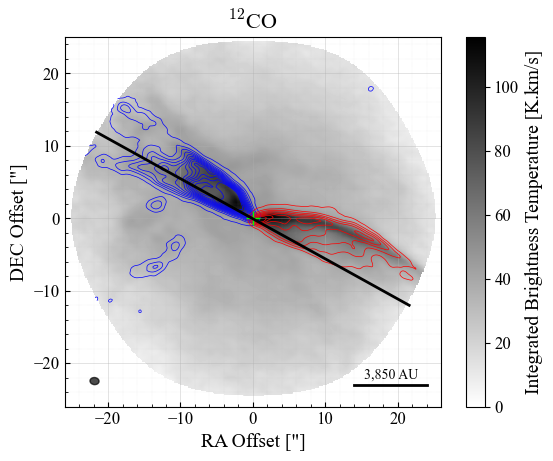

In [38]:
fig, ax = plt.subplots()
im = ax.imshow(data_12CO, origin='lower', cmap='binary', vmin=0, extent=extent)

# Add labels
ax.set_xlabel('RA Offset ["]')
ax.set_ylabel('DEC Offset ["]')
ax.set_title(r'$^{12}$CO')

# # Add velocity label in the top left of the subplot
# ax.text(0.05, 0.95, f"{v_min_12CO:.1f} to {v_max_12CO:.1f} km/s", transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im, ax=ax, label='Integrated Brightness Temperature [K.km/s]')

# Add beam
beam_12CO = beam(1.25, 0.98, 84.20, 17, 15) #beam arcseconds times pixel arcseconds for the fits file
ax.add_patch(beam_12CO)

# Set offset limits
ax.set_xlim(-26, 26)
ax.set_ylim(-25, 25)

# Set major ticks      
ax.set_xticks(np.arange(-20, 25, 10))
ax.set_yticks(np.arange(-20, 25, 10))

# Set minor ticks  
ax.set_xticks(np.arange(-26, 26, 2), minor=True)
ax.set_yticks(np.arange(-26, 26, 2), minor=True)

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 40
y_start = ax.get_ylim()[0] + 3

# Length of the bar in arcseconds
scale_bar_length = 10 # pixels (10 arcseconds in the image)

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.3)

# path_perpendicular_to_disk.show_on_axis(ax, spacing=1, color='black')

# plot_contours(data_12CO, color='black', min_level=2, max_level=10, number_of_levels=9, ax=ax)
plot_contours(data_12CO_blue, 'blue', sigma_12CO_blue, sigma_min=10, sigma_max=250, sigma_step=20, ax=ax, extent=extent)
plot_contours(data_12CO_red, 'red', sigma_12CO_red, sigma_min=180, sigma_max=450, sigma_step=40, ax=ax, extent=extent)

# plot_contours(data_12CO_blue_bullet, color='yellow', min_level=0.0222, max_level=0.175, number_of_levels=9, ax=ax)
# plot_contours(data_12CO_red_bullet, color='yellow', min_level=0.0222, max_level=0.175, number_of_levels=9, ax=ax)plot_contours(data_12CO_blue, color='blue', min_level=5, max_level=10, number_of_levels=9, ax=ax)

# Plot the protostar marker
ax.plot(0, 0, marker='+', color='lime', markersize=10, label='Marker')

ax.plot(path_ra, path_dec, color='black', linewidth=2)

# Save image
plt.savefig("HOPS164_12CO_contour_map_with_pvdiagram_path.png", format="png", dpi=300, bbox_inches="tight")

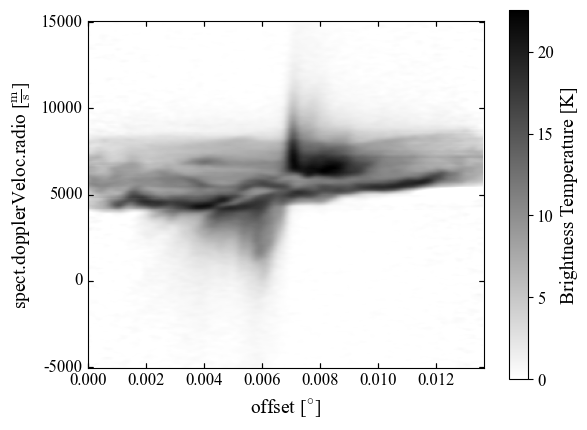

In [65]:
CO_pvdiagram = extract_pv_slice(slab_12CO, outflow_path, spacing=1) 
# CO_pvdiagram_bullets = extract_pv_slice(slab_12CO_bullets, path_perpendicular_to_disk, spacing=1) 

ax=pl.plt.axes(111,projection=wcs.WCS(CO_pvdiagram.header))
im=ax.imshow(CO_pvdiagram.data, cmap='binary', vmin=0)
cb=pl.colorbar(mappable=im)
cb.set_label('Brightness Temperature [K]')

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

In [66]:
# Get the data array from the PV diagram
data = CO_pvdiagram.data
ny, nx = data.shape
center_index = 145

# Update WCS header to match that center
pv_header_centered = CO_pvdiagram.header.copy()
pv_header_centered['CRPIX1'] = center_index + 1  # 1-based FITS indexing
pv_header_centered['CRVAL1'] = 0.0  # Center at 0 arcsec

ww = wcs.WCS(pv_header_centered)

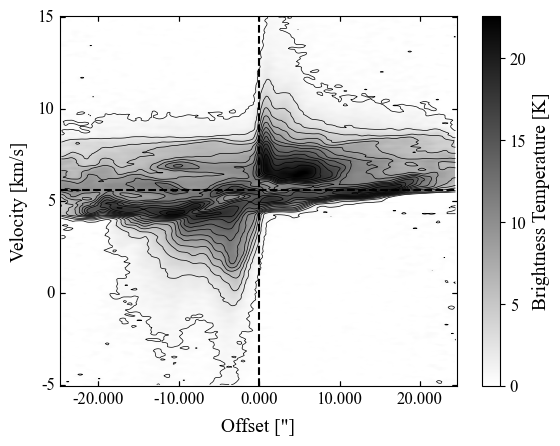

In [68]:
# Plot
fig, ax = plt.subplots(subplot_kw={'projection': ww})
im = ax.imshow(CO_pvdiagram.data, aspect='auto', cmap='binary', vmin=0)
cb = pl.colorbar(mappable=im)
cb.set_label('Brightness Temperature [K]')

ax0 = ax.coords[0]
ax0.set_format_unit(u.arcsec, decimal=True, show_decimal_unit=True)
ax1 = ax.coords[1]
ax1.set_format_unit(u.km/u.s, decimal=True, show_decimal_unit=True)

ax.set_ylabel('Velocity [km/s]')
ax.set_xlabel('Offset ["]')
ax.tick_params(axis='both', direction='in', which='both')

plot_contours(CO_pvdiagram.data, 'black', sigma_12CO, 3, 120, 10, ax=ax)

# Add guide lines
x0_pix = nx / 2 
ax.axvline(x=x0_pix, color='black', linestyle='--', label='0″ Offset')

velocity_mps = 5.6 * 1000 # kilometers
x_center = nx // 2
y56_pix = ww.wcs_world2pix([[ww.wcs_pix2world([[x_center, 0]], 0)[0][0], velocity_mps]], 0)[0][1]
ax.axhline(y=y56_pix, color='black', linestyle='--', label='5.7 km/s')

# plt.savefig("HOPS164_12CO_outflow_pvdiagram.pdf", format="pdf", dpi=300, bbox_inches="tight")
# plt.savefig("HOPS164_12CO_outflow_pvdiagram.png", format="png", dpi=300, bbox_inches="tight")


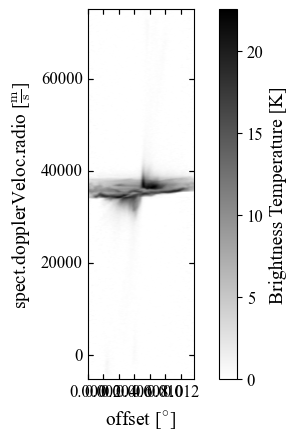

In [69]:
# Including bullets

# CO_pvdiagram = extract_pv_slice(slab_12CO, path_perpendicular_to_disk, spacing=1) 
CO_pvdiagram_bullets = extract_pv_slice(slab_12CO_bullets, outflow_path, spacing=1) 

ax=pl.plt.axes(111,projection=wcs.WCS(CO_pvdiagram.header))
im=ax.imshow(CO_pvdiagram_bullets.data, cmap='binary', vmin=0)
cb=pl.colorbar(mappable=im)
cb.set_label('Brightness Temperature [K]')

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

In [70]:
# Get the data array from the PV diagram
data = CO_pvdiagram_bullets.data
ny, nx = data.shape
center_index = 150

# Update WCS header to match that center
pv_header_centered = CO_pvdiagram_bullets.header.copy()
pv_header_centered['CRPIX1'] = center_index + 1  # 1-based FITS indexing
pv_header_centered['CRVAL1'] = 0.0  # Center at 0 arcsec

ww = wcs.WCS(pv_header_centered)

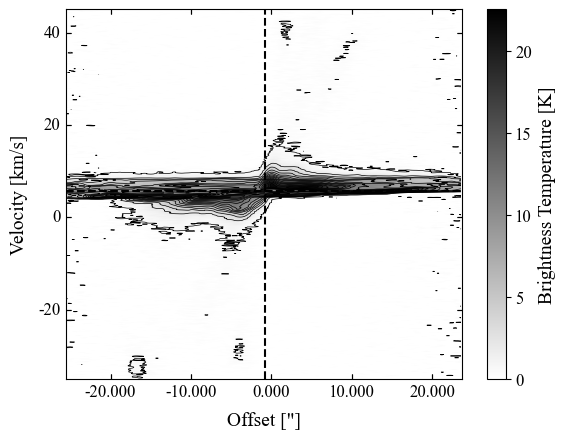

In [74]:
# Plot
fig, ax = plt.subplots(subplot_kw={'projection': ww})
im = ax.imshow(CO_pvdiagram_bullets.data, aspect='auto', cmap='binary', vmin=0)
cb = pl.colorbar(mappable=im)
cb.set_label('Brightness Temperature [K]')

ax0 = ax.coords[0]
ax0.set_format_unit(u.arcsec, decimal=True, show_decimal_unit=True)
ax1 = ax.coords[1]
ax1.set_format_unit(u.km/u.s, decimal=True, show_decimal_unit=True)

ax.set_ylabel('Velocity [km/s]')
ax.set_xlabel('Offset ["]')
ax.tick_params(axis='both', direction='in', which='both')

plot_contours(CO_pvdiagram_bullets.data, 'black', sigma_12CO, 3, 200, 9, ax=ax)

# Add guide lines
x0_pix = nx / 2 
ax.axvline(x=x0_pix, color='black', linestyle='--', label='0″ Offset')

velocity_mps = 5.6 * 1000 # kilometers
x_center = nx // 2
y56_pix = ww.wcs_world2pix([[ww.wcs_pix2world([[x_center, 0]], 0)[0][0], velocity_mps]], 0)[0][1]
ax.axhline(y=y56_pix, color='black', linestyle='--', label='5.7 km/s')

plt.savefig("HOPS164_12CO_outflow_pvdiagram_bullets.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("HOPS164_12CO_outflow_pvdiagram_bullets.png", format="png", dpi=300, bbox_inches="tight")


Setting the 'color' property will override the edgecolor or facecolor properties.


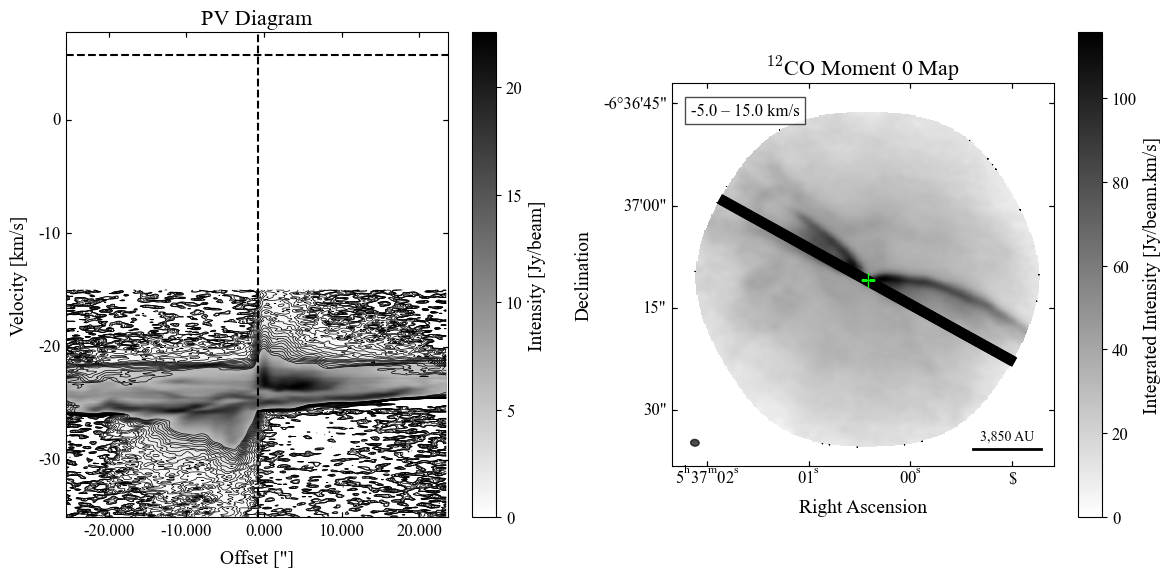

In [ ]:
fig = plt.figure(figsize=(12, 6))

# === PV Diagram (ax1) ===
ax1 = fig.add_subplot(1, 2, 1, projection=CO_ww)
im1 = ax1.imshow(CO_pvdiagram.data, aspect='auto', cmap='binary', vmin=0, origin='lower')

ax0 = ax1.coords[0]
ax0.set_format_unit(u.arcsec, decimal=True, show_decimal_unit=True)
ax00 = ax1.coords[1]
ax00.set_format_unit(u.km/u.s, decimal=True, show_decimal_unit=True)

ax1.set_xlabel('Offset ["]')
ax1.set_ylabel('Velocity [km/s]')
ax1.set_title('PV Diagram')
ax1.tick_params(axis='both', direction='in', which='both')

cb1 = plt.colorbar(im1, ax=ax1)
cb1.set_label('Intensity [Jy/beam]')

plot_contours(CO_pvdiagram.data, 'black', 0.037, 6.0, 20, ax=ax1)

# === Moment 0 Map (ax2) ===
ax2 = fig.add_subplot(1, 2, 2, projection=cube_12CO_pvdiagram.wcs.celestial)
im2 = ax2.imshow(data_12CO, origin='lower', cmap='binary', vmin=0)
ax2.tick_params(axis='both', direction='in', which='both')

# Add guide lines
ax1.axvline(x=CO_x0_pix, color='black', linestyle='--', label='0″ Offset')
ax1.axhline(y=CO_y56_pix, color='black', linestyle='--', label='5.7 km/s')

# Colorbar
cb2 = plt.colorbar(im2, ax=ax2)
cb2.set_label('Integrated Intensity [Jy/beam.km/s]')

# Plot contours on ax2
plot_contours(data_12CO, 'black', 0.037, 6.0, 20, ax2)

# Labels
ax2.set_xlabel('Right Ascension')
ax2.set_ylabel('Declination')
ax2.set_title(r'$^{12}$CO Moment 0 Map')

# Add velocity label
ax2.text(0.05, 0.95, f"{v_min_12CO:.1f} – {v_max_12CO:.1f} km/s", transform=ax2.transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

# Add beam
beam_12CO = beam(1.25/0.17, 0.98/0.17, 84.20, 80) #beam arcseconds times pixel arcseconds for the fits file
ax2.add_patch(beam_12CO)

# Set limits (adjust as needed based on real image size)
ax2.set_xlim(60, 390) 
ax2.set_ylim(60, 390)

# Scale bar setup
scale_bar_length_pix = 10 / 0.17  # pixels for 10 arcsec
x_start = ax2.get_xlim()[0] + 260  
y_start = ax2.get_ylim()[0] + 15

ax2.plot([x_start, x_start + scale_bar_length_pix], [y_start, y_start], color='black', linewidth=2)
ax2.text(x_start + scale_bar_length_pix / 2, y_start + 5, "3,850 AU", color='black', ha='center', va='bottom', fontsize=10)

# Path overlay
path_perpendicular_to_disk.show_on_axis(ax2, spacing=1, color='black')

# Plot marker
ax2.plot(229, 220, marker='+', color='lime', markersize=10, label='Marker')

plt.tight_layout()

plt.savefig("HOPS164_12CO_outflow_pvdiagram.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("HOPS164_12CO_outflow_pvdiagram.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

# 13CO

In [ ]:
cube_13CO=SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/13CO/HOPS164_13CO_Tp12m7m_Combine_pbcor_masked.fits')
cube_13CO = cube_13CO.with_spectral_unit(u.km/u.s)
cube_13CO_pvdiagram=SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/13CO/HOPS164_13CO_Tp12m7m_Combine_pbcor_masked.fits')


In [ ]:
# Chose channels with emission
v_min_13CO = 1.5
v_max_13CO = 9.5
slab_13CO = cube_13CO.spectral_slab(v_min_13CO*u.km/u.s, v_max_13CO*u.km/u.s)
slab_13CO_pvdiagram = cube_13CO_pvdiagram.spectral_slab(v_min_13CO*u.km/u.s, v_max_13CO*u.km/u.s)

# Create moment 0 map
moment0 = slab_13CO.moment(order=0)

# Access moment 0 data
data_13CO = moment0.hdu.data

In [ ]:
slab_13CO.header['BUNIT']

'Jy beam-1'

Setting the 'color' property will override the edgecolor or facecolor properties.


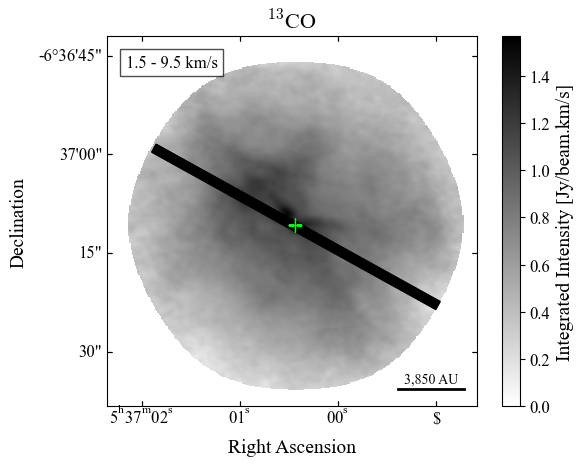

In [ ]:
fig = plt.figure()
ax = pl.plt.subplot(111, projection=cube_13CO.wcs.celestial)
im = ax.imshow(data_13CO, origin='lower', cmap='binary', vmin=0)

# Plot contours
plot_contours(data_13CO, color='black', min_level=10, max_level=25, number_of_levels=9, ax=ax)

# Plot the protostar marker
ax.plot(x_marker, y_marker, marker='+', color='lime', markersize=10, label='Marker')

# Add labels
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.set_title(r'$^{13}$CO')

# Add velocity label in the top left of the subplot
ax.text(0.05, 0.95, f"{v_min_13CO:.1f} - {v_max_13CO:.1f} km/s", transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im, ax=ax, label='Integrated Intensity [Jy/beam.km/s]')

# Add beam
beam_13CO = beam(1.29/0.17, 1.03/0.17, 84.42, 80) #beam arcseconds times pixel arcseconds for the fits file
ax2.add_patch(beam_13CO)

# Set offset limits
ax.set_xlim(60, 390) 
ax.set_ylim(60, 390)

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 260
y_start = ax.get_ylim()[0] + 15

# Length of the bar in arcseconds
scale_bar_length = 10/0.17 # pixels (10 arcseconds in the image)

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 3, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

path_perpendicular_to_disk.show_on_axis(ax, spacing=1, color='black')

# Save image
# plt.savefig("HOPS164_13CO_contour_map_with_pvdiagram_path.png", format="png", dpi=300, bbox_inches="tight")

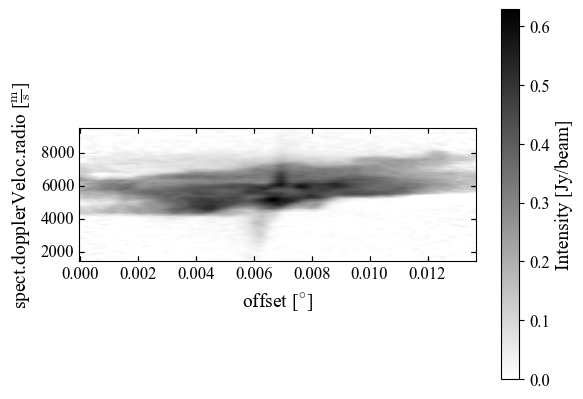

In [ ]:
s13CO_pvdiagram = extract_pv_slice(slab_13CO_pvdiagram, path_perpendicular_to_disk, spacing=1) 

ax=pl.plt.axes(111,projection=wcs.WCS(s13CO_pvdiagram.header))
im=ax.imshow(s13CO_pvdiagram.data, cmap='binary', vmin=0)
cb=pl.colorbar(mappable=im)
cb.set_label('Intensity [Jy/beam]')

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

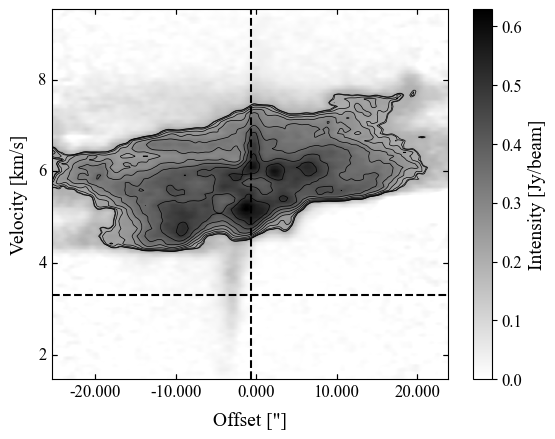

In [ ]:
# Get the data array from the PV diagram
data = s13CO_pvdiagram.data
ny, nx = data.shape

# Define offset and velocity axes
x_axis = np.arange(data.shape[1])  # Offset in pixels
y_axis = np.linspace(v_min_13CO, v_max_13CO, data.shape[0])  # Velocity in km/s

# Update WCS header to match that center
pv_header_centered = s13CO_pvdiagram.header.copy()
pv_header_centered['CRPIX1'] = center_index  # 1-based FITS indexing
pv_header_centered['CRVAL1'] = 0.0  # Center at 0 arcsec

s13CO_ww = wcs.WCS(pv_header_centered)

# Plot
ax = pl.plt.axes(111, projection=s13CO_ww)
im = ax.imshow(s13CO_pvdiagram.data, aspect='auto', cmap='binary', vmin=0)
cb = pl.colorbar(mappable=im)
cb.set_label('Intensity [Jy/beam]')

ax0 = ax.coords[0]
ax0.set_format_unit(u.arcsec, decimal=True, show_decimal_unit=True)
ax1 = ax.coords[1]
ax1.set_format_unit(u.km/u.s, decimal=True, show_decimal_unit=True)

ax.set_ylabel('Velocity [km/s]')
ax.set_xlabel('Offset ["]')
ax.tick_params(axis='both', direction='in', which='both')

plot_contours(s13CO_pvdiagram.data, 'black', 0.2, 0.5, 9, ax=ax)

# Add guide lines
s13CO_x0_pix = nx / 2
ax.axvline(x=s13CO_x0_pix, color='black', linestyle='--', label='0″ Offset')

velocity_mps = 5.6 * 1000 # kilometers
x_center = nx // 2
s13CO_y56_pix = s13CO_ww.wcs_world2pix([[s13CO_ww.wcs_pix2world([[x_center, 0]], 0)[0][0], velocity_mps]], 0)[0][1]
ax.axhline(y=y56_pix, color='black', linestyle='--', label='5.7 km/s')

Setting the 'color' property will override the edgecolor or facecolor properties.


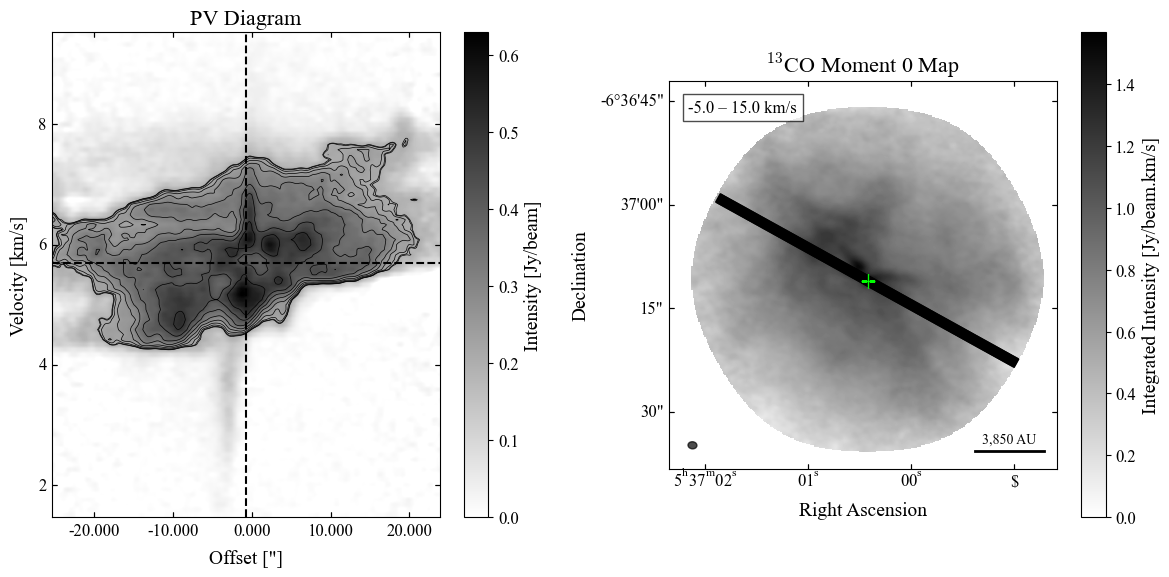

In [ ]:
fig = plt.figure(figsize=(12, 6))

# === PV Diagram (ax1) ===
ax1 = fig.add_subplot(1, 2, 1, projection=s13CO_ww)
im1 = ax1.imshow(s13CO_pvdiagram.data, aspect='auto', cmap='binary', vmin=0, origin='lower')

ax0 = ax1.coords[0]
ax0.set_format_unit(u.arcsec, decimal=True, show_decimal_unit=True)
ax00 = ax1.coords[1]
ax00.set_format_unit(u.km/u.s, decimal=True, show_decimal_unit=True)

ax1.set_xlabel('Offset ["]')
ax1.set_ylabel('Velocity [km/s]')
ax1.set_title('PV Diagram')
ax1.tick_params(axis='both', direction='in', which='both')

cb1 = plt.colorbar(im1, ax=ax1)
cb1.set_label('Intensity [Jy/beam]')

plot_contours(s13CO_pvdiagram.data, 'black', 0.2, 0.5, 9, ax=ax1)

# === Moment 0 Map (ax2) ===
ax2 = fig.add_subplot(1, 2, 2, projection=cube_12CO_pvdiagram.wcs.celestial)
im2 = ax2.imshow(data_13CO, origin='lower', cmap='binary', vmin=0)
ax2.tick_params(axis='both', direction='in', which='both')

# Add guide lines
ax1.axvline(x=s13CO_x0_pix, color='black', linestyle='--', label='0″ Offset')
ax1.axhline(y=s13CO_y56_pix, color='black', linestyle='--', label='5.7 km/s')

# Colorbar
cb2 = plt.colorbar(im2, ax=ax2)
cb2.set_label('Integrated Intensity [Jy/beam.km/s]')

# Plot contours on ax2
plot_contours(data_13CO, color='black', min_level=10, max_level=25, number_of_levels=9, ax=ax2)

# Labels
ax2.set_xlabel('Right Ascension')
ax2.set_ylabel('Declination')
ax2.set_title(r'$^{13}$CO Moment 0 Map')

# Add velocity label
ax2.text(0.05, 0.95, f"{v_min_12CO:.1f} – {v_max_12CO:.1f} km/s", transform=ax2.transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

# Add beam
beam_13CO = beam(1.29/0.17, 1.03/0.17, 84.42, 80) #beam arcseconds times pixel arcseconds for the fits file
ax2.add_patch(beam_13CO)

# Set limits (adjust as needed based on real image size)
ax2.set_xlim(60, 390) 
ax2.set_ylim(60, 390)

# Scale bar setup
scale_bar_length_pix = 10 / 0.17  # pixels for 10 arcsec
x_start = ax2.get_xlim()[0] + 260  
y_start = ax2.get_ylim()[0] + 15

ax2.plot([x_start, x_start + scale_bar_length_pix], [y_start, y_start], color='black', linewidth=2)
ax2.text(x_start + scale_bar_length_pix / 2, y_start + 5, "3,850 AU", color='black', ha='center', va='bottom', fontsize=10)

# Path overlay
path_perpendicular_to_disk.show_on_axis(ax2, spacing=1, color='black')

# Plot marker
ax2.plot(229, 220, marker='+', color='lime', markersize=10, label='Marker')

plt.tight_layout()
plt.show()

# C18O

In [ ]:
cube_C18O=SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/C18O/HOPS164_C18O_Tp12m7m_Combine_pbcor_masked.fits')
cube_C18O = cube_C18O.with_spectral_unit(u.km/u.s)


In [92]:
# Chose channels with emission
v_min_C18O = 4.0
v_max_C18O = 8.0
slab_C18O = cube_C18O.spectral_slab(v_min_C18O*u.km/u.s, v_max_C18O*u.km/u.s)
slab_C18O_pvdiagram = cube_C18O_pvdiagram.spectral_slab(v_min_C18O*u.km/u.s, v_max_C18O*u.km/u.s)

# Create moment 0 map
moment0 = slab_C18O.moment(order=0)

# Access moment 0 data
data_C18O = moment0.hdu.data

Setting the 'color' property will override the edgecolor or facecolor properties.


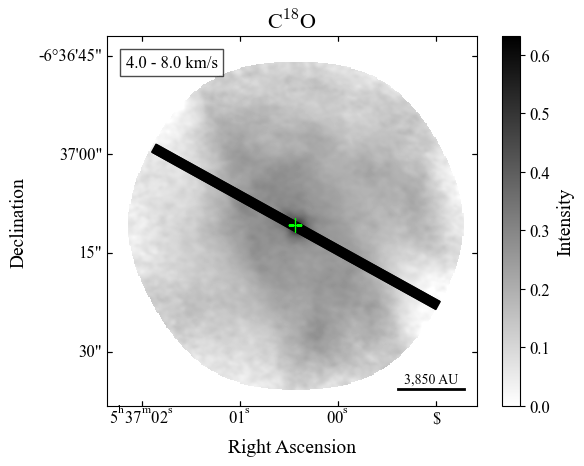

In [93]:
fig = plt.figure()
ax = pl.plt.subplot(111, projection=cube_C18O.wcs.celestial)
im = ax.imshow(data_C18O, origin='lower', cmap='binary', vmin=0)

# Plot contours
plot_contours(data_C18O, color='black', min_level=4, max_level=15, number_of_levels=9, ax=ax)

# Plot the protostar marker
ax.plot(x_marker, y_marker, marker='+', color='lime', markersize=10, label='Marker')

# Add labels
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.set_title(r'C$^{18}$O')

# Add velocity label in the top left of the subplot
ax.text(0.05, 0.95, f"{v_min_C18O:.1f} - {v_max_C18O:.1f} km/s", transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im, ax=ax, label='Intensity')

# Add beam
beam_C18O = beam(1.30/0.17, 1.03/0.17, 85.77, 80) #beam arcseconds times pixel arcseconds for the fits file
ax2.add_patch(beam_C18O)

# Set offset limits
ax.set_xlim(60, 390) 
ax.set_ylim(60, 390)

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 260
y_start = ax.get_ylim()[0] + 15

# Length of the bar in arcseconds
scale_bar_length = 10/0.17 # pixels (10 arcseconds in the image)

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 3, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

path_perpendicular_to_disk.show_on_axis(ax, spacing=1, color='black')

# Save image
# plt.savefig("HOPS164_C18O_contour_map_with_pvdiagram_path.png", format="png", dpi=300, bbox_inches="tight")

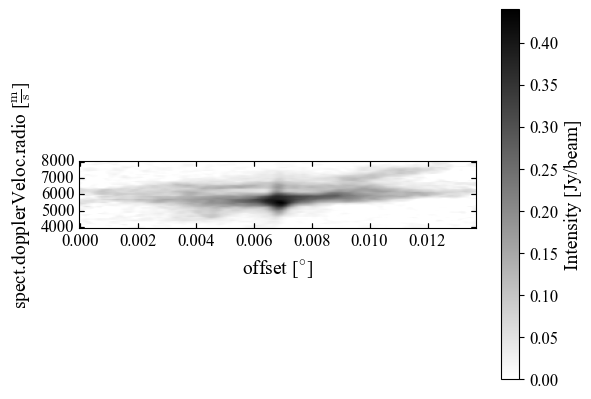

In [94]:
C18O_pvdiagram = extract_pv_slice(slab_C18O_pvdiagram, path_perpendicular_to_disk, spacing=1) 

ax=pl.plt.axes(111,projection=wcs.WCS(C18O_pvdiagram.header))
im=ax.imshow(C18O_pvdiagram.data, cmap='binary', vmin=0)
cb=pl.colorbar(mappable=im)
cb.set_label('Intensity [Jy/beam]')

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

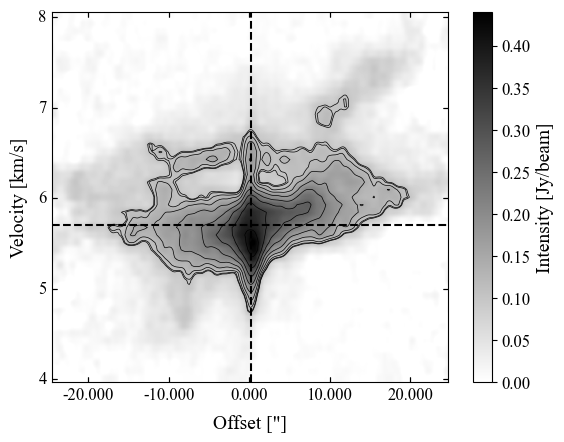

In [ ]:
# Get the data array from the PV diagram
data = C18O_pvdiagram.data
ny, nx = data.shape

# Define offset and velocity axes
x_axis = np.arange(data.shape[1])  # Offset in pixels
y_axis = np.linspace(v_min_C18O, v_max_C18O, data.shape[0])  # Velocity in km/s

# Update WCS header to match that center
pv_header_centered = C18O_pvdiagram.header.copy()
pv_header_centered['CRPIX1'] = center_index  # 1-based FITS indexing
pv_header_centered['CRVAL1'] = 0.0  # Center at 0 arcsec

C18O_ww = wcs.WCS(pv_header_centered)

# Plot
ax = pl.plt.axes(111, projection=C18O_ww)
im = ax.imshow(C18O_pvdiagram.data, aspect='auto', cmap='binary', vmin=0)
cb = pl.colorbar(mappable=im)
cb.set_label('Intensity [Jy/beam]')

ax0 = ax.coords[0]
ax0.set_format_unit(u.arcsec, decimal=True, show_decimal_unit=True)
ax1 = ax.coords[1]
ax1.set_format_unit(u.km/u.s, decimal=True, show_decimal_unit=True)

ax.set_ylabel('Velocity [km/s]')
ax.set_xlabel('Offset ["]')
ax.tick_params(axis='both', direction='in', which='both')

plot_contours(C18O_pvdiagram.data, 'black', 0.1, 0.4, 9, ax=ax)

# Add guide lines
C18O_x0_pix = nx / 2
ax.axvline(x=C18O_x0_pix, color='black', linestyle='--', label='0″ Offset')

velocity_mps = 5.6 * 1000 # kilometers
x_center = nx // 2
C18O_y56_pix = C18O_ww.wcs_world2pix([[C18O_ww.wcs_pix2world([[x_center, 0]], 0)[0][0], velocity_mps]], 0)[0][1]
ax.axhline(y=C18O_y56_pix, color='black', linestyle='--', label='5.7 km/s')

Setting the 'color' property will override the edgecolor or facecolor properties.


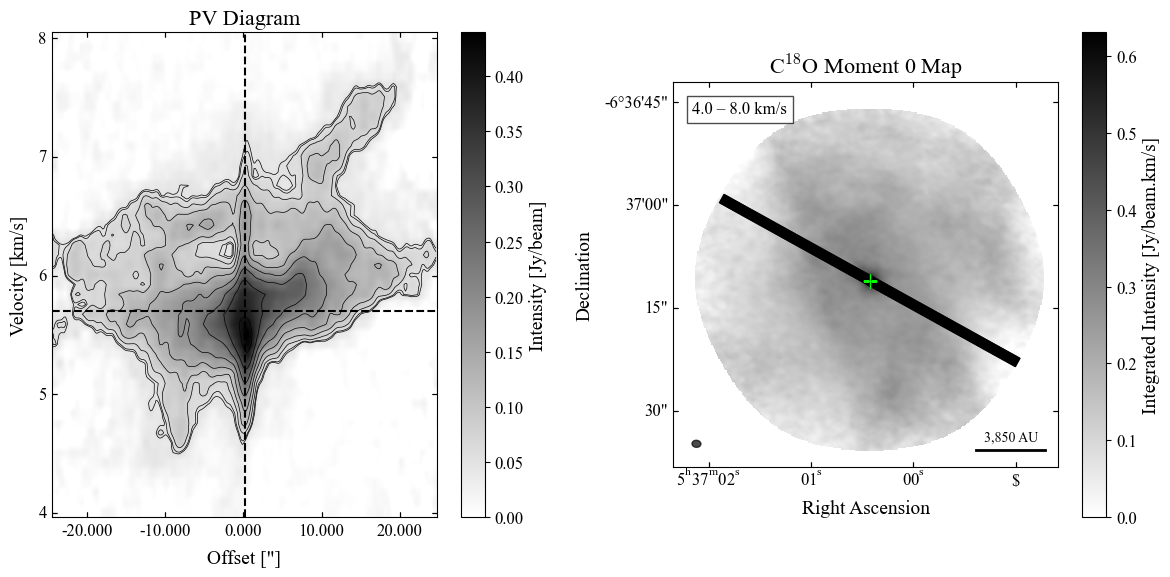

In [96]:
fig = plt.figure(figsize=(12, 6))

# === PV Diagram (ax1) ===
ax1 = fig.add_subplot(1, 2, 1, projection=C18O_ww)
im1 = ax1.imshow(C18O_pvdiagram.data, aspect='auto', cmap='binary', vmin=0, origin='lower')

ax0 = ax1.coords[0]
ax0.set_format_unit(u.arcsec, decimal=True, show_decimal_unit=True)
ax00 = ax1.coords[1]
ax00.set_format_unit(u.km/u.s, decimal=True, show_decimal_unit=True)

ax1.set_xlabel('Offset ["]')
ax1.set_ylabel('Velocity [km/s]')
ax1.set_title('PV Diagram')
ax1.tick_params(axis='both', direction='in', which='both')

cb1 = plt.colorbar(im1, ax=ax1)
cb1.set_label('Intensity [Jy/beam]')

plot_contours(C18O_pvdiagram.data, 'black', 0.05, 0.4, 9, ax=ax1)

# === Moment 0 Map (ax2) ===
ax2 = fig.add_subplot(1, 2, 2, projection=cube_C18O_pvdiagram.wcs.celestial)
im2 = ax2.imshow(data_C18O, origin='lower', cmap='binary', vmin=0)
ax2.tick_params(axis='both', direction='in', which='both')

# Add guide lines
ax1.axvline(x=C18O_x0_pix, color='black', linestyle='--', label='0″ Offset')
ax1.axhline(y=C18O_y56_pix, color='black', linestyle='--', label='5.7 km/s')

# Colorbar
cb2 = plt.colorbar(im2, ax=ax2)
cb2.set_label('Integrated Intensity [Jy/beam.km/s]')

# Plot contours on ax2
plot_contours(data_C18O, color='black', min_level=4, max_level=15, number_of_levels=9, ax=ax2)

# Labels
ax2.set_xlabel('Right Ascension')
ax2.set_ylabel('Declination')
ax2.set_title(r'C$^{18}$O Moment 0 Map')

# Add velocity label
ax2.text(0.05, 0.95, f"{v_min_C18O:.1f} – {v_max_C18O:.1f} km/s", transform=ax2.transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

# Add beam
beam_C18O = beam(1.30/0.17, 1.03/0.17, 85.77, 80) #beam arcseconds times pixel arcseconds for the fits file
ax2.add_patch(beam_C18O)

# Set limits (adjust as needed based on real image size)
ax2.set_xlim(60, 390) 
ax2.set_ylim(60, 390)

# Scale bar setup
scale_bar_length_pix = 10 / 0.17  # pixels for 10 arcsec
x_start = ax2.get_xlim()[0] + 260  
y_start = ax2.get_ylim()[0] + 15

ax2.plot([x_start, x_start + scale_bar_length_pix], [y_start, y_start], color='black', linewidth=2)
ax2.text(x_start + scale_bar_length_pix / 2, y_start + 5, "3,850 AU", color='black', ha='center', va='bottom', fontsize=10)

# Path overlay
path_perpendicular_to_disk.show_on_axis(ax2, spacing=1, color='black')

# Plot marker
ax2.plot(229, 220, marker='+', color='lime', markersize=10, label='Marker')

plt.tight_layout()
plt.show()

# H2CO

In [ ]:
cube_H2CO=SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/H2CO/HOPS164_H2CO_Tp12m7m_Combine_pbcor_masked.fits')
cube_H2CO = cube_H2CO.with_spectral_unit(u.km/u.s)

In [ ]:
# Chose channels with emission
v_min_H2CO = 3.0
v_max_H2CO = 9.5

slab_H2CO = cube_H2CO.spectral_slab(v_min_H2CO*u.km/u.s, v_max_H2CO*u.km/u.s)
slab_H2CO_pvdiagram = cube_H2CO_pvdiagram.spectral_slab(v_min_H2CO*u.km/u.s, v_max_H2CO*u.km/u.s)

# Create moment 0 map
moment0 = slab_H2CO.moment(order=0)

# Access moment 0 data
data_H2CO = moment0.hdu.data

In [ ]:
slab_H2CO.header['BUNIT']

'Jy beam-1'

Setting the 'color' property will override the edgecolor or facecolor properties.


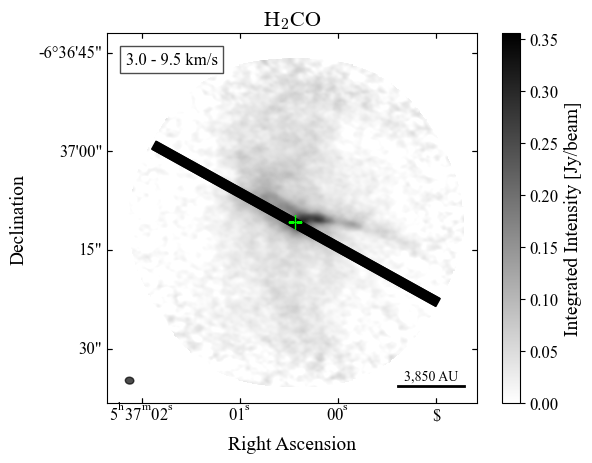

In [ ]:
fig = plt.figure()
ax = pl.plt.subplot(111, projection=cube_H2CO.wcs.celestial)
im = ax.imshow(data_H2CO, origin='lower', cmap='binary', vmin=0)

# Plot contours
plot_contours(data_H2CO, color='black', min_level=0.4, max_level=2.5, number_of_levels=5, ax=ax)

# Plot the protostar marker
ax.plot(x_marker, y_marker, marker='+', color='lime', markersize=10, label='Marker')

# Add labels
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.set_title(r'H$_2$CO')

# Add velocity label in the top left of the subplot
ax.text(0.05, 0.95, f"{v_min_H2CO:.1f} - {v_max_H2CO:.1f} km/s", transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add colorbar
plt.colorbar(im, ax=ax, label='Integrated Intensity [Jy/beam]')

# Add it to the plot
beam_H2CO = beam(1.29/0.17, 1.04/0.17, 83.63, 80) #beam arcseconds times pixel arcseconds for the fits file
ax.add_patch(beam_H2CO)

# Set offset limits
ax.set_xlim(60, 390) 
ax.set_ylim(60, 390)

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 260
y_start = ax.get_ylim()[0] + 15

# Length of the bar in arcseconds
scale_bar_length = 10/0.17 # pixels (10 arcseconds in the image)

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 3, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

path_perpendicular_to_disk.show_on_axis(ax, spacing=1, color='black')

# Save image
# plt.savefig("HOPS164_H2CO_contour_map_with_pvdiagram_path.png", format="png", dpi=300, bbox_inches="tight")

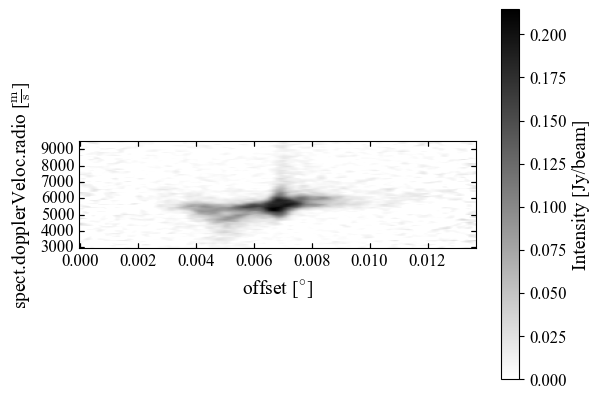

In [ ]:
H2CO_pvdiagram = extract_pv_slice(slab_H2CO_pvdiagram, path_perpendicular_to_disk, spacing=1) 

ax=pl.plt.axes(111,projection=wcs.WCS(H2CO_pvdiagram.header))
im=ax.imshow(H2CO_pvdiagram.data, cmap='binary', vmin=0)
cb=pl.colorbar(mappable=im)
cb.set_label('Intensity [Jy/beam]')

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

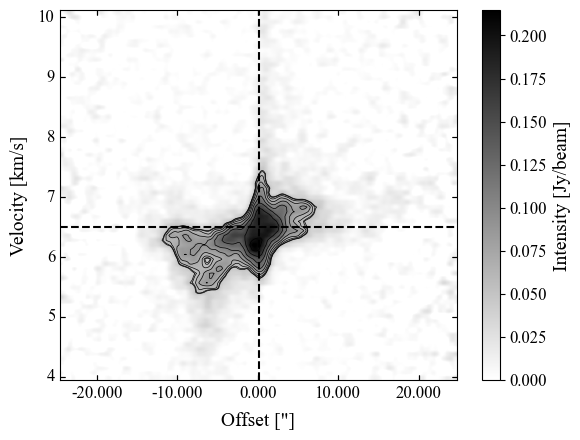

In [ ]:
# Get the data array from the PV diagram
data = H2CO_pvdiagram.data
ny, nx = data.shape

# Define offset and velocity axes
x_axis = np.arange(data.shape[1])  # Offset in pixels
y_axis = np.linspace(v_min_H2CO, v_max_H2CO, data.shape[0])  # Velocity in km/s

# Update WCS header to match that center
pv_header_centered = H2CO_pvdiagram.header.copy()
pv_header_centered['CRPIX1'] = center_index + 1  # 1-based FITS indexing
pv_header_centered['CRVAL1'] = 0.0  # Center at 0 arcsec

H2CO_ww = wcs.WCS(pv_header_centered)

# Plot
ax = pl.plt.axes(111, projection=ww)
im = ax.imshow(H2CO_pvdiagram.data, aspect='auto', cmap='binary', vmin=0)
cb = pl.colorbar(mappable=im)
cb.set_label('Intensity [Jy/beam]')

ax0 = ax.coords[0]
ax0.set_format_unit(u.arcsec, decimal=True, show_decimal_unit=True)
ax1 = ax.coords[1]
ax1.set_format_unit(u.km/u.s, decimal=True, show_decimal_unit=True)

ax.set_ylabel('Velocity [km/s]')
ax.set_xlabel('Offset ["]')
ax.tick_params(axis='both', direction='in', which='both')

plot_contours(H2CO_pvdiagram.data, 'black', 0.05, 0.2, 9, ax=ax)

# Add guide lines
H2CO_x0_pix = nx / 2
ax.axvline(x=H2CO_x0_pix, color='black', linestyle='--', label='0″ Offset')

velocity_mps = 5.6 * 1000 # kilometers
x_center = nx // 2
H2CO_y56_pix = H2CO_ww.wcs_world2pix([[H2CO_ww.wcs_pix2world([[x_center, 0]], 0)[0][0], velocity_mps]], 0)[0][1]
ax.axhline(y=H2CO_y56_pix, color='black', linestyle='--', label='5.7 km/s')


Setting the 'color' property will override the edgecolor or facecolor properties.


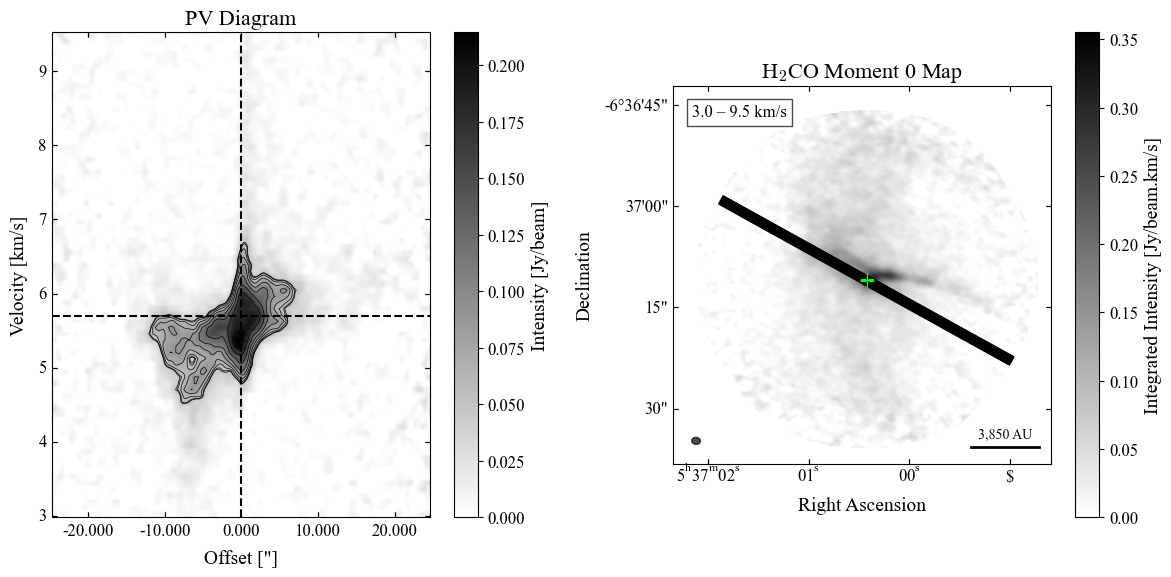

In [ ]:
fig = plt.figure(figsize=(12, 6))

# === PV Diagram (ax1) ===
ax1 = fig.add_subplot(1, 2, 1, projection=H2CO_ww)
im1 = ax1.imshow(H2CO_pvdiagram.data, aspect='auto', cmap='binary', vmin=0, origin='lower')

ax0 = ax1.coords[0]
ax0.set_format_unit(u.arcsec, decimal=True, show_decimal_unit=True)
ax00 = ax1.coords[1]
ax00.set_format_unit(u.km/u.s, decimal=True, show_decimal_unit=True)
ax1.coords[1].set_ticks(spacing=1 * u.km / u.s)


ax1.set_xlabel('Offset ["]')
ax1.set_ylabel('Velocity [km/s]')
ax1.set_title('PV Diagram')
ax1.tick_params(axis='both', direction='in', which='both')

cb1 = plt.colorbar(im1, ax=ax1)
cb1.set_label('Intensity [Jy/beam]')

plot_contours(H2CO_pvdiagram.data, 'black', 0.05, 0.2, 9, ax1)

# === Moment 0 Map (ax2) ===
ax2 = fig.add_subplot(1, 2, 2, projection=cube_H2CO_pvdiagram.wcs.celestial)
im2 = ax2.imshow(data_H2CO, origin='lower', cmap='binary', vmin=0)
ax2.tick_params(axis='both', direction='in', which='both')

# Add guide lines
ax1.axvline(x=H2CO_x0_pix, color='black', linestyle='--', label='0″ Offset')
ax1.axhline(y=H2CO_y56_pix, color='black', linestyle='--', label='5.7 km/s')

# Colorbar
cb2 = plt.colorbar(im2, ax=ax2)
cb2.set_label('Integrated Intensity [Jy/beam.km/s]')

# Plot contours on ax2
plot_contours(data_H2CO, color='black', min_level=0.4, max_level=2.5, number_of_levels=5, ax=ax2)

# Labels
ax2.set_xlabel('Right Ascension')
ax2.set_ylabel('Declination')
ax2.set_title(r'H$_2$CO Moment 0 Map')

# Add velocity label
ax2.text(0.05, 0.95, f"{v_min_H2CO:.1f} – {v_max_H2CO:.1f} km/s", transform=ax2.transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

# Add beam
beam_H2CO = beam(1.29/0.17, 1.04/0.17, 83.63, 80) #beam arcseconds times pixel arcseconds for the fits file
ax2.add_patch(beam_H2CO)

# Set limits (adjust as needed based on real image size)
ax2.set_xlim(60, 390) 
ax2.set_ylim(60, 390)

# Scale bar setup
scale_bar_length_pix = 10 / 0.17  # pixels for 10 arcsec
x_start = ax2.get_xlim()[0] + 260  
y_start = ax2.get_ylim()[0] + 15

ax2.plot([x_start, x_start + scale_bar_length_pix], [y_start, y_start], color='black', linewidth=2)
ax2.text(x_start + scale_bar_length_pix / 2, y_start + 5, "3,850 AU", color='black', ha='center', va='bottom', fontsize=10)

# Path overlay
path_perpendicular_to_disk.show_on_axis(ax2, spacing=1, color='black')

# Plot marker
ax2.plot(229, 220, marker='+', color='lime', markersize=10, label='Marker')

plt.tight_layout()
plt.show()

# N2D+ (low-res)

In [ ]:
cube_N2Dp=SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_large_sm_reb.fits')
cube_N2Dp = cube_N2Dp.with_spectral_unit(u.km/u.s).to(u.K)

# cube_N2Dp=SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_Tp12m7m_large_Combine_pbcor.fits')
# cube_N2Dp = cube_N2Dp.with_spectral_unit(u.km/u.s)

In [ ]:
v_min_N2Dp = 4.0
v_max_N2Dp = 7.5

# Chose channels with emission
slab_N2Dp = cube_N2Dp.spectral_slab(v_min_N2Dp*u.km/u.s, v_max_N2Dp*u.km/u.s)

# Create moment 0 map
data_N2Dp = slab_N2Dp.moment(order=0).hdu.data


NameError: name 'cube_N2Dp' is not defined

In [ ]:
slab_N2Dp.header['BUNIT']

'Jy beam-1'

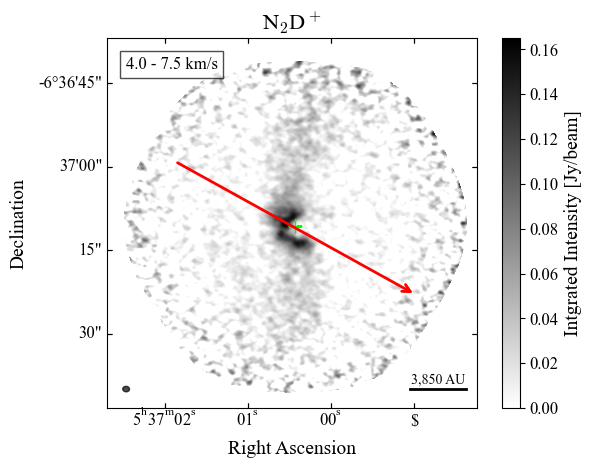

In [ ]:
fig = plt.figure()
ax = pl.plt.subplot(111, projection=cube_N2Dp.wcs.celestial)
im = ax.imshow(data_N2Dp, origin='lower', cmap='binary', vmin=0)

# Plot contours
plot_contours(data_N2Dp, color='black', min_level=0.4, max_level=2.5, number_of_levels=5, ax=ax)

# path_perpendicular_to_disk.show_on_axis(ax, spacing=1, color='black')

# Add an arrow showing direction from point1 to point2
ax.annotate(
    '', xy=point1, xytext=point2,
    arrowprops=dict(arrowstyle='->', color='red', lw=2))

# Add labels
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.set_title(r'N$_2$D$^+$')

# Add velocity label in the top left of the subplot
ax.text(0.05, 0.95, f"{v_min_N2Dp:.1f} - {v_max_N2Dp:.1f} km/s", transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

# Add it to the plot
beam_N2Dp = beam(1.22/0.17, 0.98/0.17, 84.98, 50) #beam arcseconds times pixel arcseconds for the fits file
ax.add_patch(beam_N2Dp)

# Set offset limits
ax.set_xlim(30, 420) 
ax.set_ylim(30, 420)

# Set starting point for the scale bar (in arcseconds)
x_start = ax.get_xlim()[0] + 320    
y_start = ax.get_ylim()[0] + 20  

# Length of the bar in arcseconds
scale_bar_length = 10/0.17 # pixels (10 arcseconds in the image)

# Plot the scale bar
ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

# Label it
ax.text(x_start + scale_bar_length / 2, y_start + 3, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

# Plot the protostar marker
ax.plot(x_marker, y_marker, marker='+', color='lime', markersize=10, label='Marker')

# Add colorbar
plt.colorbar(im, ax=ax, label='Intgrated Intensity [Jy/beam]')

# Save image
# plt.savefig("HOPS164_N2Dp_contour_map_with_pvdiagram_path.png", format="png", dpi=300, bbox_inches="tight")

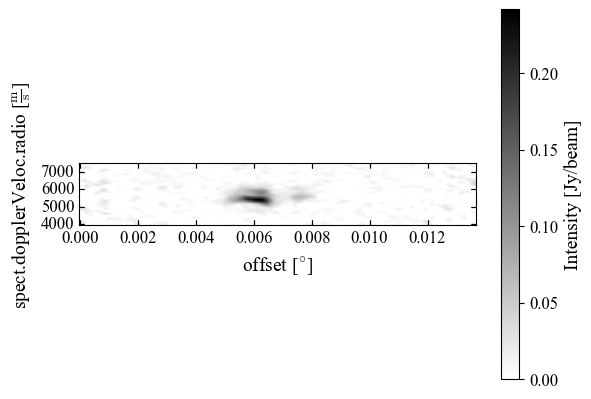

In [ ]:
N2Dp_pvdiagram = extract_pv_slice(slab_N2Dp_pvdiagram, path_perpendicular_to_disk, spacing=1) 

ax=pl.plt.axes(111,projection=wcs.WCS(N2Dp_pvdiagram.header))
im=ax.imshow(N2Dp_pvdiagram.data, cmap='binary', vmin=0)
cb=pl.colorbar(mappable=im)
cb.set_label('Intensity [Jy/beam]')

# Move ticks inside
ax.tick_params(axis='both', direction='in', which='both')

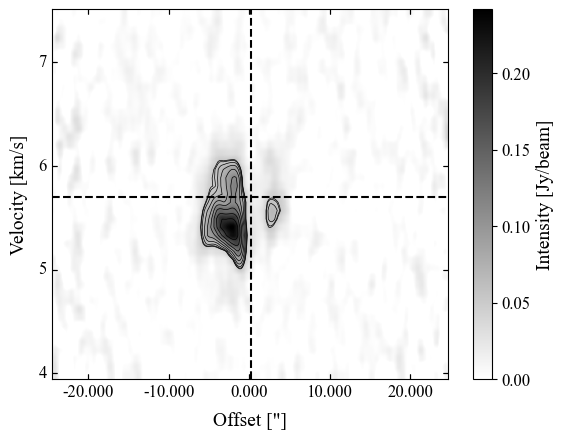

In [ ]:
# Get the data array from the PV diagram
data = N2Dp_pvdiagram.data
ny, nx = data.shape

# Define offset and velocity axes
x_axis = np.arange(data.shape[1])  # Offset in pixels
y_axis = np.linspace(v_min_N2Dp, v_max_N2Dp, data.shape[0])  # Velocity in km/s

# Center of the offset axis (pixel 145 = 0 arcsec)
center_index = 145 # center of pvdiagram

# Update WCS header to match that center
pv_header_centered = N2Dp_pvdiagram.header.copy()
pv_header_centered['CRPIX1'] = center_index  # 1-based FITS indexing
pv_header_centered['CRVAL1'] = 0.0  # Center at 0 arcsec

ww = wcs.WCS(pv_header_centered)

# Plot
ax = pl.plt.axes(111, projection=ww)
im = ax.imshow(N2Dp_pvdiagram.data, aspect='auto', cmap='binary', vmin=0)
cb = pl.colorbar(mappable=im)
cb.set_label('Intensity [Jy/beam]')

ax0 = ax.coords[0]
ax0.set_format_unit(u.arcsec, decimal=True, show_decimal_unit=True)
ax1 = ax.coords[1]
ax1.set_format_unit(u.km/u.s, decimal=True, show_decimal_unit=True)

ax.set_ylabel('Velocity [km/s]')
ax.set_xlabel('Offset ["]')
ax.tick_params(axis='both', direction='in', which='both')

plot_contours(N2Dp_pvdiagram.data, 'black', 0.05, 0.2, 9, ax)

# Add guide lines
x0_pix = nx / 2
ax.axvline(x=x0_pix, color='black', linestyle='--', label='0″ Offset')

velocity_mps = 5.6 * 1000 # kilometers
x_center = nx // 2
y56_pix = ww.wcs_world2pix([[ww.wcs_pix2world([[x_center, 0]], 0)[0][0], velocity_mps]], 0)[0][1]
ax.axhline(y=y56_pix, color='black', linestyle='--', label='5.7 km/s')


Setting the 'color' property will override the edgecolor or facecolor properties.


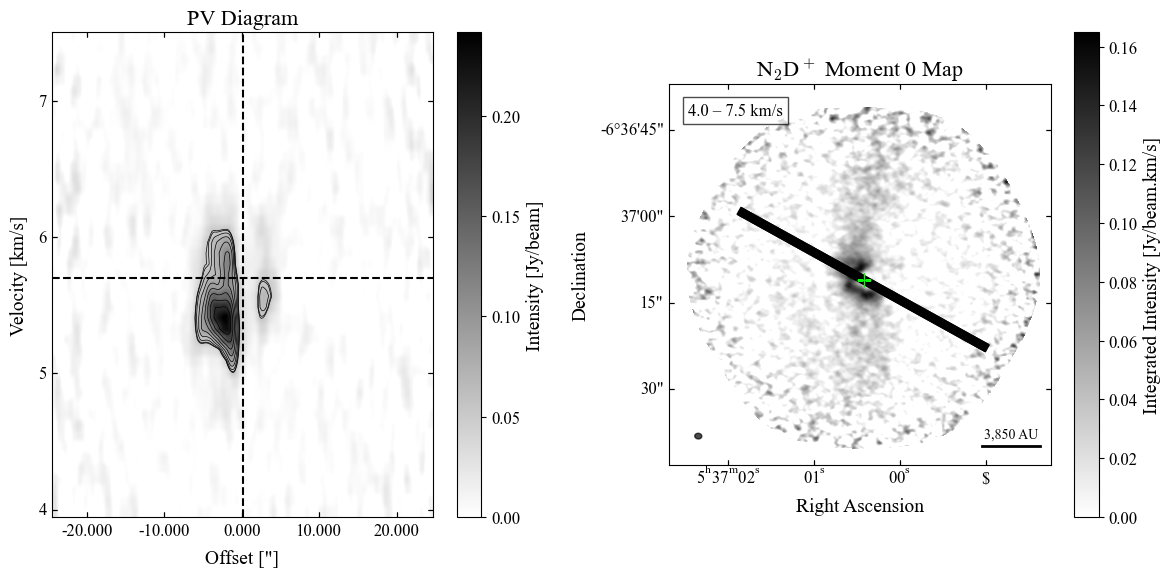

In [ ]:
fig = plt.figure(figsize=(12, 6))

# === PV Diagram (ax1) ===
ax1 = fig.add_subplot(1, 2, 1, projection=ww)
im1 = ax1.imshow(N2Dp_pvdiagram.data, aspect='auto', cmap='binary', vmin=0, origin='lower')

ax0 = ax1.coords[0]
ax0.set_format_unit(u.arcsec, decimal=True, show_decimal_unit=True)
ax00 = ax1.coords[1]
ax00.set_format_unit(u.km/u.s, decimal=True, show_decimal_unit=True)

ax1.set_xlabel('Offset ["]')
ax1.set_ylabel('Velocity [km/s]')
ax1.set_title('PV Diagram')
ax1.tick_params(axis='both', direction='in', which='both')

cb1 = plt.colorbar(im1, ax=ax1)
cb1.set_label('Intensity [Jy/beam]')

plot_contours(N2Dp_pvdiagram.data, 'black', 0.05, 0.2, 9, ax1)

# === Moment 0 Map (ax2) ===
ax2 = fig.add_subplot(1, 2, 2, projection=cube_N2Dp_pvdiagram.wcs.celestial)
im2 = ax2.imshow(data_N2Dp, origin='lower', cmap='binary', vmin=0)
ax2.tick_params(axis='both', direction='in', which='both')

# Add guide lines
ax1.axvline(x=x0_pix, color='black', linestyle='--', label='0″ Offset')
ax1.axhline(y=y56_pix, color='black', linestyle='--', label='5.7 km/s')

# Colorbar
cb2 = plt.colorbar(im2, ax=ax2)
cb2.set_label('Integrated Intensity [Jy/beam.km/s]')

# Plot contours on ax2
plot_contours(data_N2Dp, color='black', min_level=0.4, max_level=2.5, number_of_levels=5, ax=ax2)

# Labels
ax2.set_xlabel('Right Ascension')
ax2.set_ylabel('Declination')
ax2.set_title(r'N$_2$D$^+$ Moment 0 Map')

# Add velocity label
ax2.text(0.05, 0.95, f"{v_min_N2Dp:.1f} – {v_max_N2Dp:.1f} km/s", transform=ax2.transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

# Add beam
beam_N2Dp = beam(1.22/0.17, 0.98/0.17, 84.98, 60)  # use actual beam if available
ax2.add_patch(beam_N2Dp)

# Set limits (adjust as needed based on real image size)
ax2.set_xlim(30, 420) 
ax2.set_ylim(30, 420)

# Scale bar setup
scale_bar_length_pix = 10 / 0.17  # pixels for 10 arcsec
x_start = ax2.get_xlim()[0] + 320    
y_start = ax2.get_ylim()[0] + 20  

ax2.plot([x_start, x_start + scale_bar_length_pix], [y_start, y_start], color='black', linewidth=2)
ax2.text(x_start + scale_bar_length_pix / 2, y_start + 5, "3,850 AU", color='black', ha='center', va='bottom', fontsize=10)

# Path overlay
path_perpendicular_to_disk.show_on_axis(ax2, spacing=1, color='black')

# Plot marker
ax2.plot(229, 220, marker='+', color='lime', markersize=10, label='Marker')

plt.tight_layout()
plt.show()


# All PVdiagrams together

In [112]:
# Helper function
def add_panel_label(ax, label, x=0.02, y=0.98):
    ax.text(x, y, f'({label})', transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

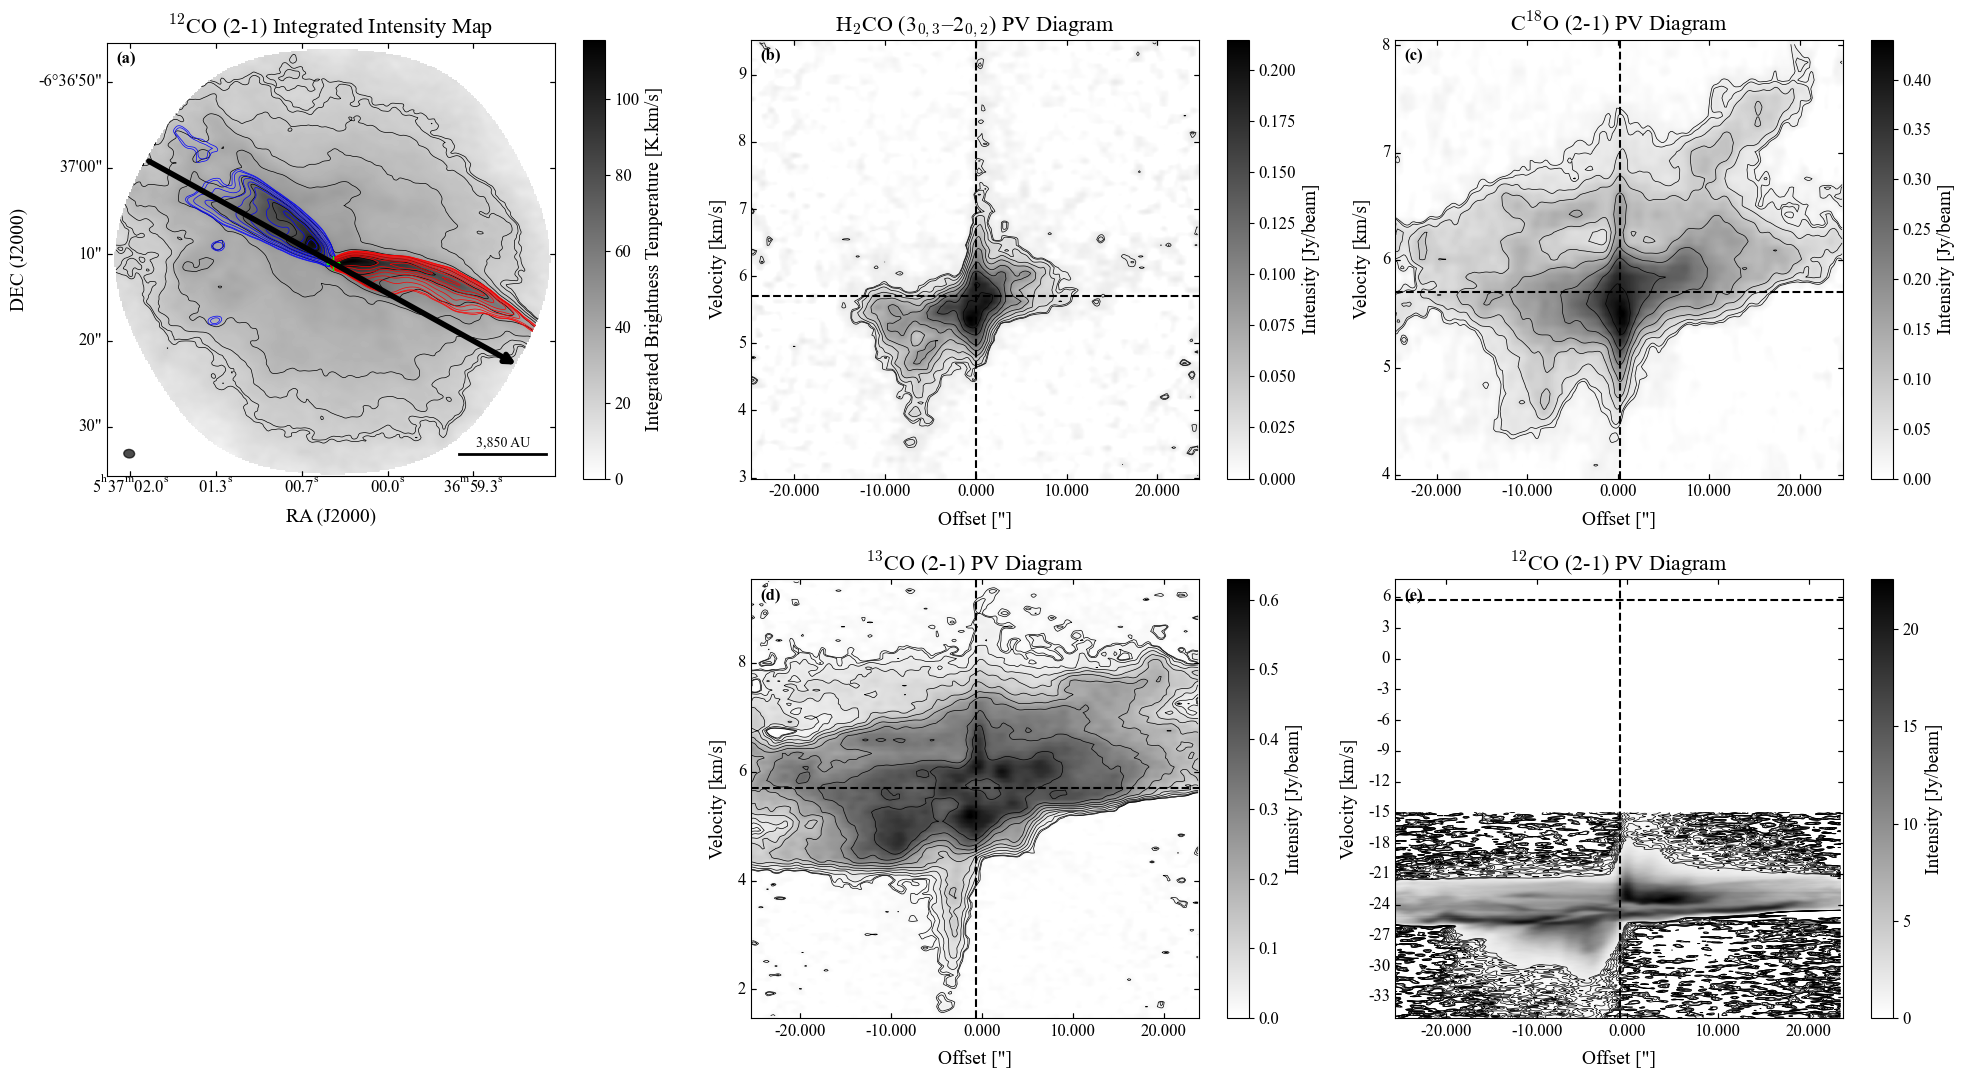

In [116]:
fig = plt.figure(figsize=(20, 11))

ax0 = fig.add_subplot(2, 3, 1, projection=cube_12CO.wcs.celestial)
# ax1 = fig.add_subplot(2, 2, 2, projection=ww)
ax2 = fig.add_subplot(2, 3, 2, projection=H2CO_ww)
ax3 = fig.add_subplot(2, 3, 3, projection=C18O_ww)
ax4 = fig.add_subplot(2, 3, 5, projection=s13CO_ww)
ax5 = fig.add_subplot(2, 3, 6, projection=CO_ww)

add_panel_label(ax0, 'a')
# add_panel_label(ax1, 'b')
add_panel_label(ax2, 'b')
add_panel_label(ax3, 'c')
add_panel_label(ax4, 'd')
add_panel_label(ax5, 'e')

# === Moment 0 Map (ax2) ===
im0 = ax0.imshow(data_12CO, origin='lower', cmap='binary', vmin=0)
ax0.tick_params(axis='both', direction='in', which='both')

# Colorbar
cb0 = plt.colorbar(im0, ax=ax0)
cb0.set_label('Integrated Brightness Temperature [K.km/s]')

# Plot contours on ax0
# plot_contours(data_12CO, color='black', min_level=20, max_level=50, number_of_levels=9, ax=ax0)
# plot_contours(data_12CO_blue, 'blue', 4, 40, 5, ax=ax0)
# plot_contours(data_12CO_red, 'red', 15, 50, 5, ax=ax0)

# Labels
ax0.set_xlabel('RA (J2000)')
ax0.set_ylabel('DEC (J2000)')
ax0.set_title(r'$^{12}$CO (2-1) Integrated Intensity Map')

# Add an arrow showing direction from point1 to point2
ax0.annotate(
    '', xy=point1, xytext=point2,
    arrowprops=dict(arrowstyle='->', color='black', lw=4),
)

# # Add velocity label
# ax0.text(0.57, 0.95, f"{v_min_N2Dp:.1f} – {v_max_N2Dp:.1f} km/s", transform=ax0.transAxes, fontsize=12,
#          verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

# Add beam
beam_12CO = beam(1.25/0.17, 0.98/0.17, 84.20, 90) #beam arcseconds times pixel arcseconds for the fits file
ax0.add_patch(beam_12CO)

# Set offset limits
ax0.set_xlim(75, 380) 
ax0.set_ylim(75, 370)

# Scale bar setup
scale_bar_length_pix = 10 / 0.17  # pixels for 10 arcsec
x_start = ax0.get_xlim()[0] + 240  
y_start = ax0.get_ylim()[0] + 15

ax0.plot([x_start, x_start + scale_bar_length_pix], [y_start, y_start], color='black', linewidth=2)
ax0.text(x_start + scale_bar_length_pix / 2, y_start + 3, "3,850 AU", color='black', ha='center', va='bottom', fontsize=10)


plot_contours(data_12CO, color='black', min_level=20, max_level=100, number_of_levels=9, ax=ax0)
# plot_contours(data_12CO_blue_bullet, color='yellow', min_level=0.0222, max_level=0.175, number_of_levels=9, ax=ax0)
# plot_contours(data_12CO_red_bullet, color='yellow', min_level=0.0222, max_level=0.175, number_of_levels=9, ax=ax0)
# plot_contours(data_12CO_red, color='red', min_level=1.0, max_level=2.5, number_of_levels=9, ax=ax0)
# plot_contours(data_12CO_blue, color='blue', min_level=0.5, max_level=2.5, number_of_levels=9, ax=ax0)

plot_contours(data_12CO_blue, color='blue', min_level=5, max_level=50, number_of_levels=9, ax=ax0)
plot_contours(data_12CO_red, color='red', min_level=20, max_level=50, number_of_levels=9, ax=ax0)

# Plot marker
ax0.plot(229, 220, marker='+', color='lime', markersize=10, label='Marker')

ax0.coords[0].set_ticks(spacing=10 * u.arcsec)
ax0.coords[1].set_ticks(spacing=10 * u.arcsec)



# # === PV Diagram (ax_N2Dp) ===
# im1 = ax1.imshow(N2Dp_pvdiagram.data, aspect='auto', cmap='binary', vmin=0, origin='lower')

# ax10 = ax1.coords[0]
# ax10.set_format_unit(u.arcsec, decimal=True, show_decimal_unit=True)
# ax100 = ax1.coords[1]
# ax100.set_format_unit(u.km/u.s, decimal=True, show_decimal_unit=True)

# ax1.set_xlabel('Offset ["]')
# ax1.set_ylabel('Velocity [km/s]')
# ax1.set_title(r'N$_2$D$^+$')
# ax1.tick_params(axis='both', direction='in', which='both')

# cb1 = plt.colorbar(im1, ax=ax1)
# cb1.set_label('Intensity [Jy/beam]')

# plot_contours(N2Dp_pvdiagram.data, 'black', 0.01, 0.2, 9, ax1)

# # Add guide lines
# ax1.axvline(x=x0_pix, color='black', linestyle='--', label='0″ Offset')
# ax1.axhline(y=y56_pix, color='black', linestyle='--', label='5.7 km/s')



# === PV Diagram (ax2) ===
im2 = ax2.imshow(H2CO_pvdiagram.data, aspect='auto', cmap='binary', vmin=0, origin='lower')

ax20 = ax2.coords[0]
ax20.set_format_unit(u.arcsec, decimal=True, show_decimal_unit=True)
ax200 = ax2.coords[1]
ax200.set_format_unit(u.km/u.s, decimal=True, show_decimal_unit=True)
ax2.coords[1].set_ticks(spacing=1 * u.km / u.s)


ax2.set_xlabel('Offset ["]')
ax2.set_ylabel('Velocity [km/s]')
ax2.set_title(r'H$_2$CO (3$_{0,3}$–2$_{0,2}$) PV Diagram')
ax2.tick_params(axis='both', direction='in', which='both')

cb2 = plt.colorbar(im2, ax=ax2)
cb2.set_label('Intensity [Jy/beam]')

plot_contours(H2CO_pvdiagram.data, 'black', 0.0186, 0.23, 10, ax2)

# Add guide lines
ax2.axvline(x=H2CO_x0_pix, color='black', linestyle='--', label='0″ Offset')
ax2.axhline(y=H2CO_y56_pix, color='black', linestyle='--', label='5.7 km/s')



# === PV Diagram (ax3) ===
im3 = ax3.imshow(C18O_pvdiagram.data, aspect='auto', cmap='binary', vmin=0, origin='lower')

ax30 = ax3.coords[0]
ax30.set_format_unit(u.arcsec, decimal=True, show_decimal_unit=True)
ax300 = ax3.coords[1]
ax300.set_format_unit(u.km/u.s, decimal=True, show_decimal_unit=True)

ax3.set_xlabel('Offset ["]')
ax3.set_ylabel('Velocity [km/s]')
ax3.set_title(r'C$^{18}$O (2-1) PV Diagram')
ax3.tick_params(axis='both', direction='in', which='both')

cb3 = plt.colorbar(im3, ax=ax3)
cb3.set_label('Intensity [Jy/beam]')

plot_contours(C18O_pvdiagram.data, 'black', 0.0279, 0.605, 10, ax=ax3)

# Add guide lines
ax3.axvline(x=C18O_x0_pix, color='black', linestyle='--', label='0″ Offset')
ax3.axhline(y=C18O_y56_pix, color='black', linestyle='--', label='5.7 km/s')



# === PV Diagram (ax4) ===
im4 = ax4.imshow(s13CO_pvdiagram.data, aspect='auto', cmap='binary', vmin=0, origin='lower')

ax40 = ax4.coords[0]
ax40.set_format_unit(u.arcsec, decimal=True, show_decimal_unit=True)
ax400 = ax4.coords[1]
ax400.set_format_unit(u.km/u.s, decimal=True, show_decimal_unit=True)

ax4.set_xlabel('Offset ["]')
ax4.set_ylabel('Velocity [km/s]')
ax4.set_title(r'$^{13}$CO (2-1) PV Diagram')
ax4.tick_params(axis='both', direction='in', which='both')

cb4 = plt.colorbar(im4, ax=ax4)
cb4.set_label('Intensity [Jy/beam]')

plot_contours(s13CO_pvdiagram.data, 'black', 0.0216, 0.432, 10, ax=ax4)

# Add guide lines
ax4.axvline(x=s13CO_x0_pix, color='black', linestyle='--', label='0″ Offset')
ax4.axhline(y=s13CO_y56_pix, color='black', linestyle='--', label='5.7 km/s')



# === PV Diagram (ax5) ===
im5 = ax5.imshow(CO_pvdiagram.data, aspect='auto', cmap='binary', vmin=0, origin='lower')

ax50 = ax5.coords[0]
ax50.set_format_unit(u.arcsec, decimal=True, show_decimal_unit=True)
ax500 = ax5.coords[1]
ax500.set_format_unit(u.km/u.s, decimal=True, show_decimal_unit=True)

ax5.set_xlabel('Offset ["]')
ax5.set_ylabel('Velocity [km/s]')
ax5.set_title(r'$^{12}$CO (2-1) PV Diagram')
ax5.tick_params(axis='both', direction='in', which='both')

cb5 = plt.colorbar(im5, ax=ax5)
cb5.set_label('Intensity [Jy/beam]')

plot_contours(CO_pvdiagram.data, 'black', 0.0222, 1.2728, 10, ax=ax5)

# Add guide lines
ax5.axvline(x=CO_x0_pix, color='black', linestyle='--', label='0″ Offset')
ax5.axhline(y=CO_y56_pix, color='black', linestyle='--', label='5.7 km/s')
ax5.coords[1].set_ticks(spacing=3 * u.km / u.s)


plt.savefig("HOPS164_all_outflow_pvdiagrams.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("HOPS164_all_outflow_pvdiagrams.png", format="png", dpi=300, bbox_inches="tight")

plt.tight_layout()